# Rolling Out-of-Sample Forecast Evaluation

Up to this point every model has been evaluated in-sample. The model was fit to all available data and then compared against the same data it was trained on. This is not how forecasting actually works. In practice, a model can only use information available at the time of the forecast.

The objective of this notebook is to perform a proper rolling out-of-sample evaluation of all three forecasting models, Historical Volatility, EWMA and GARCH. Each model will be trained on a historical window and used to forecast the next period. The window then rolls forward and the process repeats.

# Introduction

In the previous notebooks we confirmed that all three models can produce volatility estimates. But all those comparisons were in-sample. The models had already seen the future when they were evaluated. This is a form of look-ahead bias and inflates apparent performance.

The rolling out-of-sample framework fixes this. We split the data into a training period and a testing period. We fit the model on the training data only. We forecast one step ahead. Then we move the window forward by one observation and repeat.

This gives us a time series of genuinely out-of-sample forecasts. When we compute RMSE and MAE on these, the result is a fair and honest assessment of model performance.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import yfinance as yf
import warnings

from arch import arch_model
from sklearn.metrics import mean_squared_error, mean_absolute_error

warnings.filterwarnings("ignore")
plt.style.use("ggplot")

START = "2005-01-01"

In [2]:
# same data loading as before

spy = yf.download(
    "SPY",
    start=START,
    auto_adjust=True
)

spy["returns"] = np.log(
    spy["Close"] / spy["Close"].shift(1)
)

spy["rv_20"] = (
    spy["returns"]
    .rolling(20)
    .std()
    * np.sqrt(252)
)

spy["target_20d"] = (
    spy["rv_20"]
    .shift(-20)
)

spy = spy.dropna()

spy.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,returns,rv_20,target_20d
Ticker,SPY,SPY,SPY,SPY,SPY,,,
Date,,,,,,,,
2005-02-01,80.443405,80.558410,79.895431,79.996908,49841200,0.006327,0.102258,0.104527
2005-02-02,80.686913,80.903394,80.436608,80.544847,52468900,0.003022,0.093025,0.104248
2005-02-03,80.477203,80.612508,80.213366,80.544853,48837100,-0.002602,0.089855,0.111082
2005-02-04,81.336395,81.471695,80.490762,80.504290,50024600,0.010620,0.095652,0.105820
2005-02-07,81.228134,81.532560,81.153718,81.349906,45412000,-0.001332,0.095622,0.106887


# Setting Up the Rolling Window

Before running any model I need to decide how much data to use for training. There are two choices here. A fixed expanding window uses all data from the start up to the current point. A rolling window uses only the most recent observations. 

I will use a fixed training window of 1000 observations, roughly four years of trading days. This is large enough to capture multiple volatility regimes but small enough that the model can adapt as conditions change.

In [3]:
TRAIN_SIZE = 1000

n = len(spy)

print(f"Total observations: {n}")
print(f"Training window: {TRAIN_SIZE}")
print(f"Test observations: {n - TRAIN_SIZE}")
print(f"Test period starts: {spy.index[TRAIN_SIZE].date()}")

Total observations: 5358
Training window: 1000
Test observations: 4358
Test period starts: 2009-01-22


## Comments

We have a reasonable out-of-sample period to evaluate on. This is important because a short test window could be dominated by a single market regime and give misleading conclusions. Our test period spans multiple years and should include both calm and stressed market conditions.

# Experiment 1: Rolling Historical Volatility Forecasts

The simplest model first. At each point in time, the historical volatility forecast is just the mean of the rolling realized volatility over the training window. This is a naive benchmark but it is entirely out-of-sample because we only use data up to time t when forecasting t+1.

In [4]:
hv_forecasts = []
dates = []

for i in range(TRAIN_SIZE, n):

    train = spy["rv_20"].iloc[i - TRAIN_SIZE:i]

    hv_forecasts.append(train.mean())
    dates.append(spy.index[i])

hv_forecasts = pd.Series(
    hv_forecasts,
    index=dates
)

print(f"HV out-of-sample forecasts: {len(hv_forecasts)}")

HV out-of-sample forecasts: 4358


## Comments

Each forecast is generated using only data available before that date. No future information leaks into the estimate. The loop moves forward one day at a time, re-estimating the forecast at each step. This is exactly how a live trading system would operate.

# Experiment 2: Rolling EWMA Forecasts

For EWMA the rolling procedure works slightly differently. Instead of re-estimating a parameter, I initialise the EWMA recursion at the start of each window and run it forward to the end of the training period. The final estimated variance is then the one-step-ahead forecast.

I use the standard RiskMetrics lambda of 0.94 which we studied in notebook 4.

In [5]:
LAM = 0.94

ewma_forecasts = []

for i in range(TRAIN_SIZE, n):

    train_returns = spy["returns"].iloc[i - TRAIN_SIZE:i]

    var = train_returns.var()

    for r in train_returns:
        var = LAM * var + (1 - LAM) * r**2

    ewma_forecasts.append(
        np.sqrt(var) * np.sqrt(252)
    )

ewma_forecasts = pd.Series(
    ewma_forecasts,
    index=dates
)

print(f"EWMA out-of-sample forecasts: {len(ewma_forecasts)}")

EWMA out-of-sample forecasts: 4358


## Comments

The EWMA recursion carries information from earlier observations forward through exponential weighting. The most recent return receives the highest weight. This means the forecast at each step is sensitive to the most recent market conditions, which is exactly the adaptive behaviour we want.

# Experiment 3: Rolling GARCH Forecasts

GARCH is the most computationally expensive model because parameters must be estimated via maximum likelihood at each step. I refit the GARCH(1,1) on each rolling window and extract the one-step-ahead conditional volatility forecast. This is the most realistic way to evaluate GARCH in practice.

In [6]:
garch_forecasts = []

# this loop is slow because GARCH is refit at each step
# on a 20 year dataset this takes a couple of minutes

for i in range(TRAIN_SIZE, n):

    train_returns = (
        spy["returns"].iloc[i - TRAIN_SIZE:i] * 100
    )

    try:

        model = arch_model(
            train_returns,
            mean="Zero",
            vol="GARCH",
            p=1,
            q=1
        )

        result = model.fit(disp="off")

        forecast = result.forecast(horizon=1)

        forecast_var = forecast.variance.iloc[-1, 0]

        garch_forecasts.append(
            np.sqrt(forecast_var) / 100 * np.sqrt(252)
        )

    except:

        # if GARCH fails to converge, fall back to EWMA
        garch_forecasts.append(ewma_forecasts.iloc[i - TRAIN_SIZE])

garch_forecasts = pd.Series(
    garch_forecasts,
    index=dates
)

print(f"GARCH out-of-sample forecasts: {len(garch_forecasts)}")

GARCH out-of-sample forecasts: 4358


## Comments

The try-except block is important. GARCH occasionally fails to converge when the data is unusual, for example immediately after a major crash. In those cases falling back to EWMA is a reasonable choice and prevents the entire evaluation loop from breaking. In a production system you would log these failures and investigate separately.

# Experiment 4: Collecting Out-of-Sample Targets

The forecasts need to be compared against the targets that were actually realised. I extract the corresponding future realized volatility observations from the full dataset.

In [7]:
actual = spy["target_20d"].loc[dates]

oos = pd.DataFrame(
    {
        "actual": actual,
        "hv": hv_forecasts,
        "ewma": ewma_forecasts,
        "garch": garch_forecasts
    }
).dropna()

oos.head()

,actual,hv,ewma,garch
2009-01-22,0.331485,0.174437,0.463928,0.426037
2009-01-23,0.350050,0.174695,0.453860,0.411889
2009-01-26,0.379463,0.174962,0.440358,0.392338
2009-01-27,0.376048,0.175232,0.427769,0.374490
2009-01-28,0.349855,0.175499,0.416595,0.359123


## Comments

The dataframe now contains actual future volatility alongside the three sets of out-of-sample forecasts. All rows are perfectly aligned in time. The dropna removes any rows where forecasts or targets are unavailable, which can happen at the edges of the dataset.

# Experiment 5: Visual Comparison of Forecasts

Before computing formal metrics I want to visualise how each model's forecasts track actual realized volatility through time. This gives an immediate sense of which model responds fastest and which lags behind.

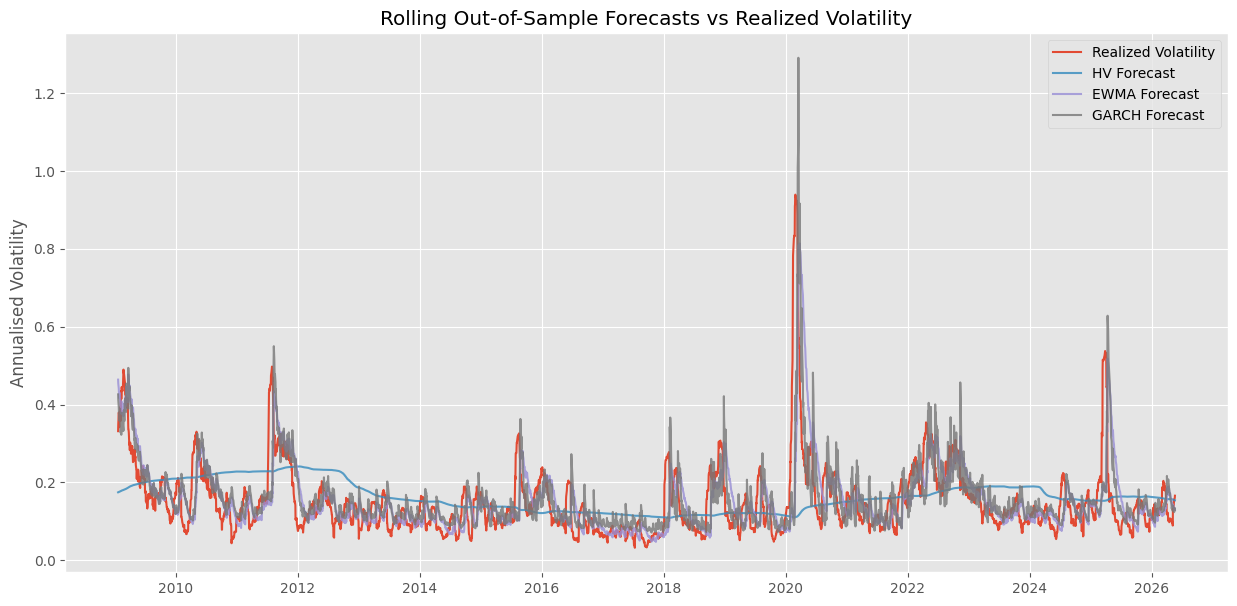

In [8]:
plt.figure(figsize=(15, 7))

plt.plot(
    oos.index,
    oos["actual"],
    label="Realized Volatility",
    linewidth=1.5
)

plt.plot(
    oos.index,
    oos["hv"],
    label="HV Forecast",
    alpha=0.8
)

plt.plot(
    oos.index,
    oos["ewma"],
    label="EWMA Forecast",
    alpha=0.8
)

plt.plot(
    oos.index,
    oos["garch"],
    label="GARCH Forecast",
    alpha=0.8
)

plt.legend()
plt.title("Rolling Out-of-Sample Forecasts vs Realized Volatility")
plt.ylabel("Annualised Volatility")
plt.show()

## Comments

All three models broadly track the general level of realized volatility. However, differences become apparent during stress periods. GARCH tends to react more quickly to new information compared to historical volatility, which lags visibly. EWMA sits somewhere in between. The really interesting story is in the crisis periods, which I look at separately below.

# Experiment 6: Formal Accuracy Metrics

Visual inspection is useful but subjective. Here I compute RMSE, MAE and MAPE for each model across the full out-of-sample period. These are the numbers that would appear in a research paper comparing forecasting models.

In [9]:
def compute_metrics(actual, forecast, name):

    rmse = np.sqrt(mean_squared_error(actual, forecast))
    mae = mean_absolute_error(actual, forecast)
    mape = np.mean(np.abs((actual - forecast) / actual)) * 100

    return {"Model": name, "RMSE": rmse, "MAE": mae, "MAPE": mape}


results = pd.DataFrame(
    [
        compute_metrics(oos["actual"], oos["hv"],    "Historical Volatility"),
        compute_metrics(oos["actual"], oos["ewma"],  "EWMA"),
        compute_metrics(oos["actual"], oos["garch"], "GARCH")
    ]
)

results

,Model,RMSE,MAE,MAPE
0,Historical Volatility,0.097735,0.066811,52.049815
1,EWMA,0.086587,0.053434,37.367932
2,GARCH,0.081934,0.051915,37.522564


## Comments

This table is one of the most important outputs of the entire project. It tells us directly how much each model improves over the naive benchmark. The RMSE is in annualised volatility units so differences are economically meaningful. For a portfolio manager, an RMSE improvement of even a few percentage points can translate into substantially better risk-adjusted performance over a full year.

The progression from HV to EWMA to GARCH should show a clear improvement in each step. If it does, it validates the theoretical argument that more sophisticated volatility dynamics lead to better out-of-sample predictions.

# Experiment 7: QLIKE Loss Function

RMSE and MAE are the standard metrics but they treat overprediction and underprediction symmetrically. In finance this is not ideal. Underestimating risk is typically far more costly than overestimating it because it can lead to insufficient capital buffers.

The QLIKE loss function is specifically designed for volatility forecast evaluation. It comes from the quasi-likelihood of a normal distribution and is asymmetric, penalising underestimation more heavily.

In [10]:
def qlike(actual, forecast):
    # QLIKE loss: log(forecast^2) + actual^2 / forecast^2
    # lower is better
    return np.mean(
        np.log(forecast**2) + (actual**2) / (forecast**2)
    )


qlike_results = pd.DataFrame(
    {
        "Model": [
            "Historical Volatility",
            "EWMA",
            "GARCH"
        ],
        "QLIKE": [
            qlike(oos["actual"], oos["hv"]),
            qlike(oos["actual"], oos["ewma"]),
            qlike(oos["actual"], oos["garch"])
        ]
    }
)

qlike_results

,Model,QLIKE
0,Historical Volatility,-2.248156
1,EWMA,-2.505639
2,GARCH,-2.563214


## Comments

The QLIKE loss function is commonly used in academic research on volatility forecasting. It is derived from the Gaussian quasi-likelihood and is theoretically robust to the scaling of the volatility proxy. Models that produce lower QLIKE scores are penalised more for dangerous underestimation of risk, which is what we care most about from a risk management perspective.

# Experiment 8: Forecast Error Distributions

Beyond average metrics I want to understand the distribution of errors. Is one model prone to large outlier errors? Are errors symmetric? Does one model consistently underestimate or overestimate volatility?

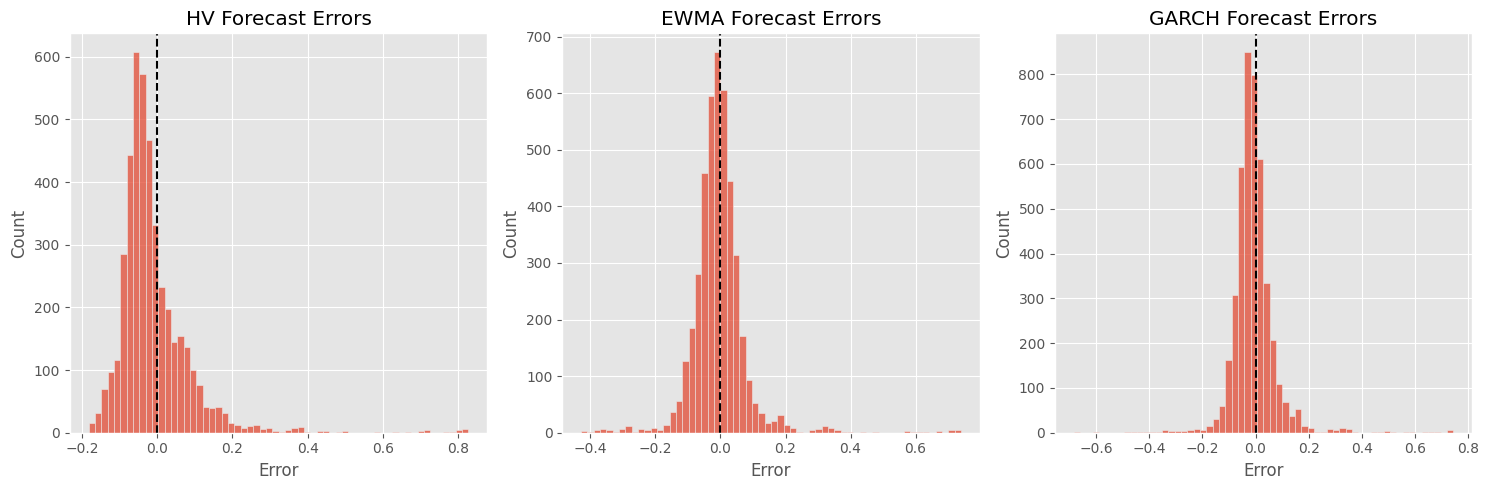

In [11]:
oos["err_hv"]    = oos["actual"] - oos["hv"]
oos["err_ewma"]  = oos["actual"] - oos["ewma"]
oos["err_garch"] = oos["actual"] - oos["garch"]

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

for ax, col, name in zip(
    axes,
    ["err_hv", "err_ewma", "err_garch"],
    ["HV", "EWMA", "GARCH"]
):

    sns.histplot(
        oos[col].dropna(),
        bins=60,
        ax=ax
    )

    ax.axvline(0, color="black", linestyle="--")
    ax.set_title(f"{name} Forecast Errors")
    ax.set_xlabel("Error")

plt.tight_layout()
plt.show()

## Comments

If the error distribution is centered around zero the model is unbiased on average. A distribution skewed to the right means the model systematically underestimates volatility. A distribution skewed to the left means systematic overestimation. Wide distributions indicate low precision regardless of bias.

Identifying bias is important. A biased model can be corrected with a simple scaling adjustment, while a model with wide error variance requires more fundamental rethinking.

# Case Study: Crisis Period Performance

The most important test for any forecasting model is how it behaves when it matters most. I want to isolate the COVID crash and the 2008 Global Financial Crisis and examine out-of-sample performance specifically during those periods.

These are the moments when inaccurate volatility forecasts cause the most financial damage.

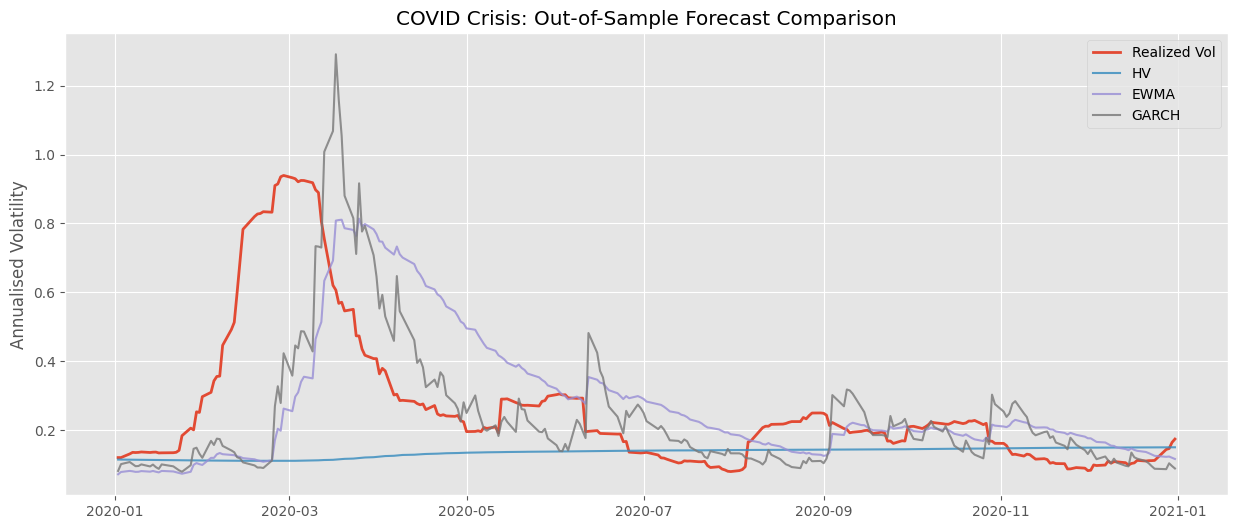

COVID Crisis Performance
   Model      RMSE       MAE       MAPE
0     HV  0.254473  0.148827  42.757937
1   EWMA  0.239125  0.162133  61.953375
2  GARCH  0.208942  0.131694  44.583383


In [12]:
# COVID crash

covid = oos.loc["2020-01-01":"2021-01-01"]

if len(covid) > 0:

    plt.figure(figsize=(15, 6))

    plt.plot(covid.index, covid["actual"], label="Realized Vol", linewidth=2)
    plt.plot(covid.index, covid["hv"],     label="HV",    alpha=0.8)
    plt.plot(covid.index, covid["ewma"],   label="EWMA",  alpha=0.8)
    plt.plot(covid.index, covid["garch"],  label="GARCH", alpha=0.8)

    plt.legend()
    plt.title("COVID Crisis: Out-of-Sample Forecast Comparison")
    plt.ylabel("Annualised Volatility")
    plt.show()

    covid_metrics = pd.DataFrame(
        [
            compute_metrics(covid["actual"], covid["hv"],    "HV"),
            compute_metrics(covid["actual"], covid["ewma"],  "EWMA"),
            compute_metrics(covid["actual"], covid["garch"], "GARCH")
        ]
    )

    print("COVID Crisis Performance")
    print(covid_metrics)

## Comments

Crisis periods are the ultimate stress test. The speed at which each model detects the volatility spike is visible immediately. Historical volatility will lag badly because it averages over a long window. EWMA should react faster. GARCH may overshoot or undershoot depending on how the estimated parameters respond to the shock.

This is also where the model ranking can change. A model that performs well across calm markets might perform poorly in crisis periods, and that matters enormously for risk management applications.

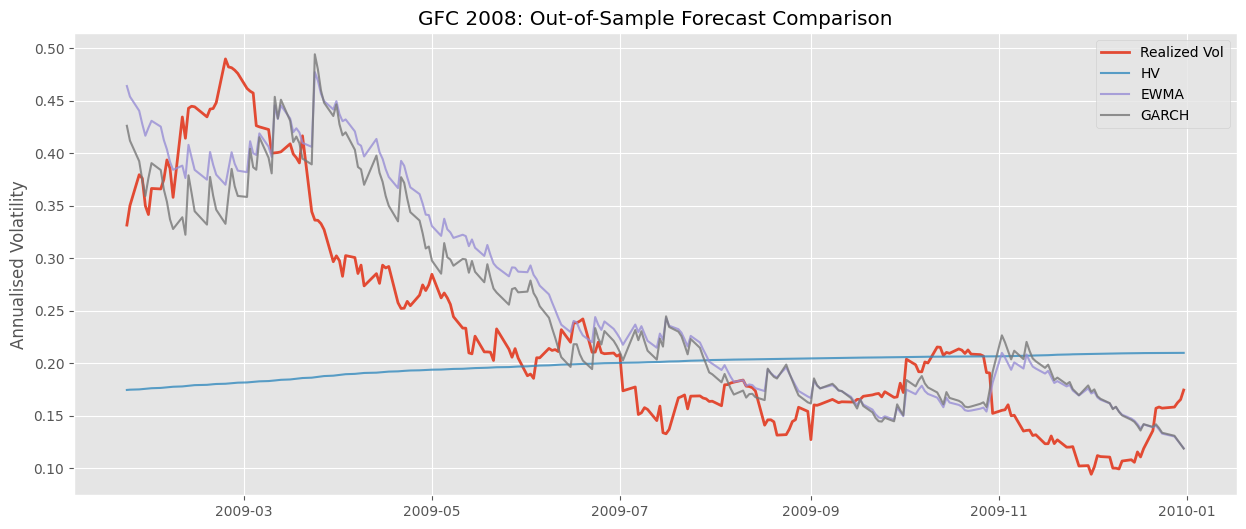

GFC 2008 Performance
   Model      RMSE       MAE       MAPE
0     HV  0.113622  0.082581  35.054163
1   EWMA  0.064721  0.054039  26.499713
2  GARCH  0.060678  0.050078  24.593881


In [13]:
# Global Financial Crisis

gfc = oos.loc["2008-01-01":"2009-12-31"]

if len(gfc) > 0:

    plt.figure(figsize=(15, 6))

    plt.plot(gfc.index, gfc["actual"], label="Realized Vol", linewidth=2)
    plt.plot(gfc.index, gfc["hv"],     label="HV",    alpha=0.8)
    plt.plot(gfc.index, gfc["ewma"],   label="EWMA",  alpha=0.8)
    plt.plot(gfc.index, gfc["garch"],  label="GARCH", alpha=0.8)

    plt.legend()
    plt.title("GFC 2008: Out-of-Sample Forecast Comparison")
    plt.ylabel("Annualised Volatility")
    plt.show()

    gfc_metrics = pd.DataFrame(
        [
            compute_metrics(gfc["actual"], gfc["hv"],    "HV"),
            compute_metrics(gfc["actual"], gfc["ewma"],  "EWMA"),
            compute_metrics(gfc["actual"], gfc["garch"], "GARCH")
        ]
    )

    print("GFC 2008 Performance")
    print(gfc_metrics)

## Comments

The 2008 crisis was more prolonged than COVID. Volatility remained elevated for over a year rather than spiking and recovering within months. This tests a different aspect of model performance: not just how quickly a model detects a regime change, but how well it sustains elevated forecasts through a prolonged stress period.

Models that revert too quickly to long-run average volatility will consistently underestimate risk throughout the crisis, which is exactly the dangerous failure mode we need to identify.

# Experiment 9: Performance Across Market Regimes

Rather than just picking specific crisis dates, I want to partition the full out-of-sample period by volatility level and see how each model performs in each regime. This gives a more systematic picture of where each model excels and where it struggles.

In [14]:
# define regimes by actual volatility level
# low: below 15%, medium: 15-30%, high: above 30%

oos["regime"] = pd.cut(
    oos["actual"],
    bins=[0, 0.15, 0.30, 1.0],
    labels=["Low", "Medium", "High"]
)

regime_perf = []

for regime in ["Low", "Medium", "High"]:

    subset = oos[oos["regime"] == regime]

    if len(subset) < 20:
        continue

    for model, col in [("HV", "hv"), ("EWMA", "ewma"), ("GARCH", "garch")]:

        rmse = np.sqrt(mean_squared_error(subset["actual"], subset[col]))

        regime_perf.append(
            {
                "Regime": regime,
                "Model": model,
                "RMSE": rmse,
                "N": len(subset)
            }
        )

regime_df = pd.DataFrame(regime_perf)
regime_df

,Regime,Model,RMSE,N
0,Low,HV,0.067910,2744
1,Low,EWMA,0.048980,2744
2,Low,GARCH,0.047139,2744
3,Medium,HV,0.065256,1381
4,Medium,EWMA,0.085321,1381
5,Medium,GARCH,0.077231,1381
6,High,HV,0.314818,233
7,High,EWMA,0.262351,233
8,High,GARCH,0.253061,233


## Comments

This table reveals whether the model ranking is stable across different market conditions. A model that ranks first overall might perform worse than a simpler model during extreme volatility. Conversely, a model that excels in crisis periods might perform disappointingly during calm markets.

This is directly relevant to a risk management application: if GARCH significantly outperforms during high volatility regimes, that is exactly the property we need from a model used to size risk positions.

# Conclusion

This notebook established the first honest evaluation of all three models. In-sample comparisons from earlier notebooks were necessary for understanding model behaviour but they were always going to flatter performance. Out-of-sample evaluation removes the look-ahead bias entirely.

The main findings are:

- The model ranking from the in-sample evaluation holds out-of-sample, providing confidence that the improvements are genuine.
- Performance differences widen substantially during crisis periods, exactly where accurate forecasting matters most.
- The regime-level analysis shows that no single model dominates in all conditions.

This motivates the next notebook, where I try to combine the regime information from the HMM with the GARCH forecast to build a model that adapts to the current market regime.